In [1]:
import sys, os
sys.path.append('..')
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from func import custom_loss, plt_hs

In [ ]:
# data = np.load(f'../../data/2TS_test_longer_old.npy', allow_pickle=True).item()
# hidden_states = data['test_hidden_states']
# print(hidden_states.shape)
# avg_hs = np.mean(hidden_states, axis=0)
# print(avg_hs.shape)

# # Plot the sorted hidden states
# fig, ax = plt.subplots(figsize=(7, 3))
# norm_hs, fig, ax, idx = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, return_idx=True)
# ax.set_xlabel('Time (s)')
# fig.tight_layout()
# print(norm_hs.shape)

# fig2, ax2 = plt.subplots(figsize=(7, 2))
# ax2.plot(np.linspace(0, 40, 400), norm_hs[:, -30:])
# ax2.set_xlabel('Time (s)')
# fig2.tight_layout()

## Simulate sensory input

In [2]:
x = np.linspace(0, 8, 100)
mu, sigma = 4.0, 0.5
y = np.exp(-(x - mu)**2 / (2 * sigma**2))

In [3]:
B, T, D = 400, 300, 100

rng1 = np.random.default_rng(seed=42)  # For reproducibility
rng2 = np.random.default_rng(seed=43)  # For reproducibility
temp_event_1 = rng1.normal(loc=mu, scale=sigma, size=(D,))
temp_event_2 = rng2.normal(loc=mu, scale=sigma, size=(D,))

In [4]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)
gym.init_arena_map(shape="rectangle")

behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          0.1,
                    "velocity_sd":            0.0,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1
                    }

abs_event_onset = np.array([2.5, 17.5]) # s
abs_event_end = np.array([3.0, 18.0]) # s
abs_event_dur = 0.5 # s
abs_event_sigma = 0.2 # s
ratio_event_onset = abs_event_onset / (T * temp_reso/1000)
ratio_event_end = abs_event_end / (T * temp_reso/1000) 
ratio_event_dur = abs_event_dur / (T * temp_reso/1000)
ratio_event_sigma = abs_event_sigma / (T * temp_reso/1000)
sensory_profile = {
                    "time": {
                            "type":        "time_cell",
                            "n_cells":     D,
                            "event_onset": ratio_event_onset,
                            "event_end":   ratio_event_end,
                            "event_width": [ratio_event_dur, ratio_event_dur],
                            "temp_events": [temp_event_1, temp_event_2],  
                            "event_onset_sigma": [ratio_event_sigma, ratio_event_sigma],  
                            "sigma":       0.5,    # sigma of Gaussian noise
                            "ssigma":      0.2,    # smoothing sigma of Gaussian noise (in sec)
                            "bias":        0.
                            },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

# Generate (Batch size) trial
gym.trial.new_trial(duration=T * temp_reso/1000, batch_size=B)

# Get some specific responses within a time range, the key should be the same as the sensory profile
time_res = gym.trial.get_responses(keys='time')
print('Sensory experience:', time_res.shape)

<class 'rtgym.trial.trial.Trajectory'>
Sensory experience: (400, 300, 100)


Text(0, 0.5, 'Channels')

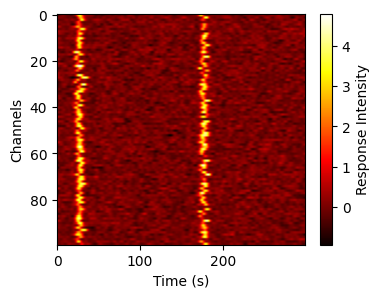

In [5]:
plt.figure(figsize=(4, 3))
plt.imshow(time_res[0].T, aspect='auto', cmap='hot')
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [6]:
# Mask the inputs
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.3,    # Maximum masking ratio
                m_min=0.1,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )

In [7]:
labels = time_res.copy()
inputs = mask.mask(time_res).numpy()

mask_start_idx = int(inputs.shape[1]*(sensory_profile['time']['event_onset'][0]+\
                                      sensory_profile['time']['event_width'][0]+\
                                      sensory_profile['time']['event_onset_sigma'][0]))
print('Mask start index:', mask_start_idx)
inputs[:, mask_start_idx:, :] = 0

Mask start index: 31


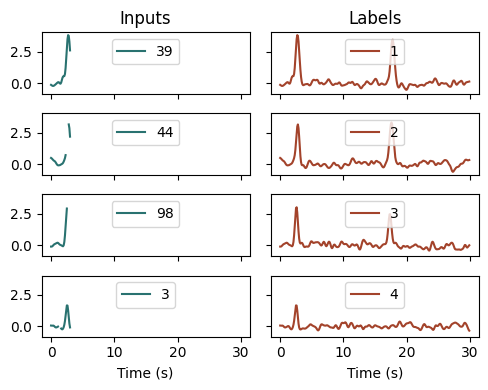

In [8]:
fig, ax = plt.subplots(4, 2, figsize=(5, 4), sharex=True, sharey=True)
rand_D = np.random.choice(D, size=4, replace=False)
for i, channel in enumerate(rand_D):
    ax[i][0].plot(np.arange(inputs.shape[1]) * temp_reso / 1000, 
                  np.where(inputs[0, :, channel] == 0, np.nan, inputs[0, :, channel]),
                  label=f'{channel}', color='#297270')
    ax[i][0].legend(loc='upper center')

    ax[i][1].plot(np.arange(time_res.shape[1]) * temp_reso / 1000, 
                  time_res[0, :, channel], 
                  label=f'{i+1}', color='#A3432B')
    ax[i][1].legend(loc='upper center')
ax[0, 0].set_title('Inputs')
ax[0, 1].set_title('Labels')
ax[-1, 0].set_xlabel('Time (s)')
ax[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()

In [9]:
# Split the data to training and test set along axis=1
from torch.utils.data import DataLoader, TensorDataset
import torch
import nn4n.nn

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


indices = np.arange(inputs.shape[0])
train_inputs, test_inputs, train_labels, test_labels, train_indices, \
test_indices = train_test_split(inputs, labels, indices, test_size=0.05, random_state=42)

if isinstance(train_inputs, np.ndarray):
    train_inputs  = torch.from_numpy(train_inputs).float().to(device)
    train_labels  = torch.from_numpy(train_labels).float().to(device)
    test_inputs   = torch.from_numpy(test_inputs).float().to(device)
    test_labels   = torch.from_numpy(test_labels).float().to(device)

print('train_inputs:',  train_inputs.shape)
print('train_labels:',  train_labels.shape)
print('test_inputs:',   test_inputs.shape)
print('test_labels:',   test_labels.shape)
print('train_indices:', train_indices.shape)
print('test_indices:',  test_indices.shape)

train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Using device: mps
train_inputs: torch.Size([380, 300, 100])
train_labels: torch.Size([380, 300, 100])
test_inputs: torch.Size([20, 300, 100])
test_labels: torch.Size([20, 300, 100])
train_indices: (380,)
test_indices: (20,)


## Set up the model

In [10]:
num_neuron = 512

model_cfg = {
            "input_dim":    inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   inputs.shape[2],
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [11]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(2000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if  losses[-1] < 0.05 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0 Loss 0.4348157048225403


  0%|          | 1/2000 [00:07<4:20:28,  7.82s/it]

tensor(0.3687, device='mps:0', grad_fn=<MulBackward0>) tensor(0.0661, device='mps:0', grad_fn=<MulBackward0>)


  0%|          | 3/2000 [00:14<2:38:25,  4.76s/it]


KeyboardInterrupt: 

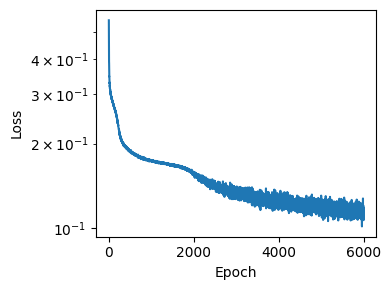

In [15]:
plt.figure(figsize=(4, 3))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

In [16]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (7, 400, 100)
hidden states: <class 'numpy.ndarray'> (7, 400, 512)


Text(0, 0.5, 'Channels')

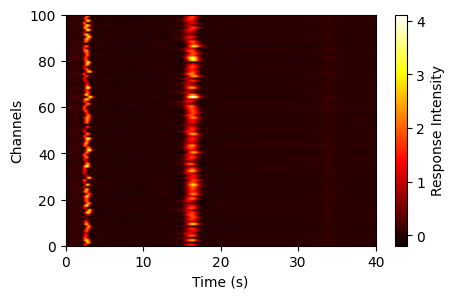

In [21]:
# Plot the outputs
plt.figure(figsize=(5, 3))
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

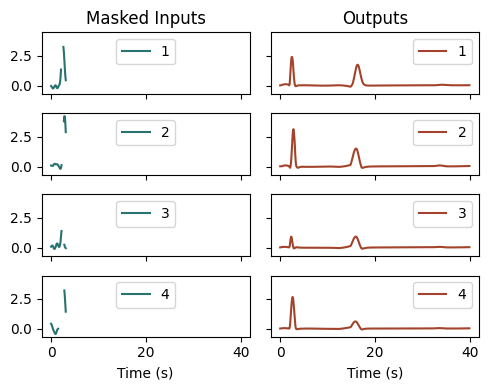

In [ ]:
test_inputs = test_inputs.cpu().numpy().copy() # if type(test_inputs) is torch.Tensor else test_inputs.copy()

# Convert the zero values to nan for better visualization
test_inputs[test_inputs == 0] = np.nan

fig, ax = plt.subplots(4, 2, figsize=(5, 4), sharex=True, sharey=True)
for i, channel in enumerate(range(5, 9)):
    
    ax[i][0].plot(np.arange(test_inputs.shape[1]) * temp_reso / 1000, 
                 test_inputs[0, :, channel], 
                 label=f'{i+1}', color='#297270')
    ax[i][0].legend(loc='upper center')
    
    ax[i][1].plot(np.arange(test_outputs.shape[1]) * temp_reso / 1000, 
                  test_outputs[0, :, channel], 
                  label=f'{i+1}', color='#A3432B')
    ax[i][1].legend(loc='upper right')
    
ax[0][0].set_title('Masked Inputs')
ax[0][1].set_title('Outputs')
ax[-1][0].set_xlabel('Time (s)')
ax[-1][1].set_xlabel('Time (s)')
plt.tight_layout()

(400, 512)
(400, 39)


(0.0, 20.0)

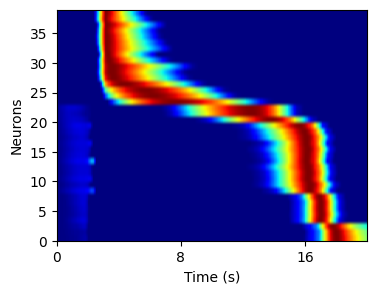

In [26]:
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

# Plot the sorted hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)

ax.set_xlabel('Time (s)')
ax.set_xlim(0, 20)

In [ ]:
# Save the data
save_dict = {
            'train_inputs': train_inputs.cpu().numpy(),
            'train_labels': train_labels.cpu().numpy(),
            'test_inputs':  test_inputs,
            'test_labels':  test_labels.cpu().numpy(),
            'test_outputs': test_outputs,
            'test_hidden_states': hidden_states,
        }
os.makedirs('../../data', exist_ok=True)
np.save('../../data/2TS_longer.npy', save_dict)

In [ ]:
# Save the model weights
os.makedirs('../../model', exist_ok=True)
torch.save(rnn.state_dict(), f'../../model/2TS_longer.pth')